<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/NER_LB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NER**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [NER_LB]()

**Fecha:** Mayor 2026


### **Objetivo:** Aplicar CFR para el reconocimiento de entidades nombradas al conjunto de datos proporcionado.

In [1]:
### Drive connection

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **1. Carga de conjunto de datos**

In [2]:
import pandas as pd

In [8]:
### Carga de archivo

NER_df = pd.read_csv('/content/drive/MyDrive/Procesamiento Lenguaje Natural/split1.mx-news.txt', sep = '\t')

In [9]:
### Vista previa de los primeros  datos
display('Vista previa de los primeros  datos', NER_df)

### Número de filas
print(f'Número total de filas: {NER_df['Sentence #'].count()} \n')

### Count de nulls
print('Número de valores nulos encontrados:\n', NER_df.isnull().sum())

'Vista previa de los primeros  datos'

,Sentence #,Word,Pos,Tag
0,Sentence 1,Interesante,ADJ,O
1,Sentence 1,será,VLfin,O
2,Sentence 1,conocer,VLinf,O
3,Sentence 1,las,ART,O
4,Sentence 1,reflexiones,NC,O
...,...,...,...,...
49313,Sentence 1295,edificio,NC,O
49314,Sentence 1295,de,PDEL,O
49315,Sentence 1295,la,NC,O
49316,Sentence 1295,Cancillería,PREP,S-ORG


Número total de filas: 49318 

Número de valores nulos encontrados:
 Sentence #    0
Word          0
Pos           0
Tag           0
dtype: int64


## **2. Preprocesamiento de datos para generar frases**

In [10]:
### Función para agrupar oraciones de archivo txt

def group_sentence(NER_df):
    sentence_list = []
    label_list = []
    grouped = NER_df.groupby("Sentence #")

    for _,group in grouped:
        sentence = [(w,p) for w, p  in zip(group["Word"],group["Pos"])]
        label = group["Tag"].values
        sentence_list.append(sentence)
        label_list.append(label)
    return sentence_list,label_list

In [11]:
### Función de exctractor de features

def word2features(sent,i):
    word, postag = sent[i]
    features = {
        "word.lower(),": word.lower(),
        "postag": postag,
        "is_title": word.istitle(),
        "is_upper": word.isupper(),
        "is_digit": word.isdigit()
    }
    if i > 0:
        prev_word, prev_pos = sent[i - 1]
        features.update({
            "-1:word.lower()": prev_word.lower(),
            "-1:postag": prev_pos
        })
    else:
        features["BOS"] = True

    if i < len(sent) -1:
        next_word, next_pos = sent[i + 1]
        features.update({
            "+1:word.lower()": next_word.lower(),
            "+1:postag": next_pos
        })
    else:
        features["EOS"] = True

    return features

###
def sent2features(sent):
    return [word2features(sent,i) for i in range(len(sent))]

In [13]:
### Comprobación de agrupación de oraciones

### Agrupación de listas para crear oraciones
sentence_list,label_list = group_sentence(NER_df)

print('Sentence 1:')
display(sentence_list[0])


Sentence 1:


[('Interesante', 'ADJ'),
 ('será', 'VLfin'),
 ('conocer', 'VLinf'),
 ('las', 'ART'),
 ('reflexiones', 'NC'),
 ('de', 'PREP'),
 ('Pedro', 'NP'),
 ('Kumamoto', 'NC'),
 ('en', 'PREP'),
 ('torno', 'NC'),
 ('a', 'PREP'),
 ('este', 'DM'),
 ('fracaso', 'NC'),
 (',', 'CM'),
 ('por', 'PREP'),
 ('el', 'ART'),
 ('momento', 'NC'),
 ('lo', 'ART'),
 ('único', 'NC'),
 ('que', 'CQUE'),
 ('ha', 'VHfin'),
 ('dicho', 'QU'),
 ('es', 'VSfin'),
 ('que', 'CQUE'),
 ('al', 'PAL'),
 ('interior', 'NC'),
 ('de', 'PREP'),
 ('su', 'PPO'),
 ('grupo', 'NC'),
 ('existen', 'VLfin'),
 ('dos', 'CARD'),
 ('planteamientos', 'NC'),
 (',', 'CM'),
 ('uno', 'CARD'),
 ('seguir', 'VLinf'),
 ('por', 'PREP'),
 ('la', 'ART'),
 ('ruta', 'NC'),
 ('independiente', 'ADJ'),
 (',', 'CM'),
 ('el', 'ART'),
 ('otro', 'QU'),
 ('destaca', 'VLfin'),
 ('las', 'ART'),
 ('bondades', 'NC'),
 ('de', 'CSUBI'),
 ('fundar', 'VLinf'),
 ('una', 'ART'),
 ('agrupación', 'NC'),
 ('o', 'CC'),
 ('un', 'ART'),
 ('partido', 'NC'),
 ('político', 'ADJ'),
 ('.', 

In [14]:
### Etiquetas de la primer oración

print('Labels from sentence 1:')
display(label_list[0])

Labels from sentence 1:


array(['O', 'O', 'O', 'O', 'O', 'O', 'B-PER', 'E-PER', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O',
       'O', 'O', 'O'], dtype=object)

## **3. Generar conjunto de entrenamiento de modelo**

Generar el conjunto de entrenamiento con 80% de las frases y 20% de las oraciones para el test

In [15]:
!pip install sklearn-crfsuite

In [16]:
from sklearn.model_selection import train_test_split
import sklearn_crfsuite


In [17]:
### División de frases, con 80% para entrenamiento, 20% para test

sentence_train, sentence_test, label_train, label_test = train_test_split( sentence_list,
                                                                          label_list,
                                                                          test_size=0.20,
                                                                           random_state=42
                                                                           )

In [18]:
### Preparación de datos

X_train = [sent2features(s) for s in sentence_train]
y_train = label_train
X_test = [sent2features(s) for s in sentence_test]
y_test = label_test


### **Entrenar CRF**

In [19]:
crf = sklearn_crfsuite.CRF(
    algorithm="lbfgs",
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)

CRF(algorithm='lbfgs', all_possible_transitions=True, max_iterations=100)

## **4. Evaluación de desempeño del modelo**

Para evaluar el desempenno del modelo CRF se utiliza sklearn-crfsuite, para obtener las métricas de clasificación como accuracy, F1-score, precision y recall.

In [20]:
from sklearn_crfsuite import metrics

In [21]:
### Predicciones sobre el conjunto de prueba

y_pred = crf.predict(X_test)

### Reporte de clasificación
print('Reporte de clasificación')
print(metrics.flat_classification_report(y_test, y_pred, digits=3))


Reporte de clasificación
              precision    recall  f1-score   support

       B-ADD      0.875     0.636     0.737        11
       B-AGE      1.000     0.750     0.857         8
       B-DAT      0.921     0.891     0.906        92
       B-DOC      1.000     0.235     0.381        17
       B-EVT      0.778     0.412     0.538        17
       B-FAC      1.000     0.455     0.625        11
       B-GPE      0.880     0.667     0.759        33
       B-LOC      1.000     0.500     0.667         2
       B-MNY      1.000     0.833     0.909        12
       B-ORG      0.764     0.773     0.768        88
       B-PER      0.838     0.915     0.875       153
       B-PEX      1.000     0.571     0.727        14
       B-PRC      1.000     0.600     0.750         5
       B-PRO      1.000     0.222     0.364         9
       B-TIM      1.000     0.783     0.878        23
       B-TIT      0.767     0.524     0.623        63
       E-ADD      0.875     0.636     0.737        11
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **Evaluación con F1-score**

In [22]:
f1_score = metrics.flat_f1_score(y_test, y_pred, average='weighted')
print("F1-score ponderado:", f1_score)


F1-score ponderado: 0.9252739909579175


Al aplicar una evaluación de F1-Score vemos que el modelo tiene un score de 0.9253 esto indica que el modelo CFR tiene un buen equilibrio entre precisión y recall.

El modelo fue capaz de predicr correctamente la mayorí de las etiquetas con pocos falsos positivos y falsos netativos.

## **5. Matriz de confusión**

In [23]:
from sklearn_crfsuite.utils import flatten
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [24]:
### Crear el arreglo

y_test_flat = flatten(y_test)
y_pred_flat = flatten(y_pred)

labels = list(set(y_test_flat))
print(labels)

['E-TIT', 'E-PRC', 'I-ORG', 'B-TIM', 'E-DOC', 'I-DOC', 'I-PER', 'B-ADD', 'B-GPE', 'E-TIM', 'I-GPE', 'E-EVT', 'B-PRC', 'I-FAC', 'E-ADD', 'E-GPE', 'S-TIM', 'E-ORG', 'I-LOC', 'I-MNY', 'S-GPE', 'I-TIT', 'I-PRC', 'B-LOC', 'S-ORG', 'I-TIM', 'B-TIT', 'B-EVT', 'S-EVT', 'E-LOC', 'B-MNY', 'S-PEX', 'I-PEX', 'O', 'E-PEX', 'E-DAT', 'E-PRO', 'I-DAT', 'E-FAC', 'S-DOC', 'B-PER', 'E-AGE', 'B-DAT', 'B-AGE', 'S-TIT', 'E-MNY', 'I-PRO', 'S-PER', 'B-FAC', 'S-DEM', 'B-PRO', 'I-EVT', 'B-ORG', 'S-FAC', 'S-DAT', 'E-PER', 'S-ADD', 'I-ADD', 'S-PRO', 'B-DOC', 'B-PEX']


In [25]:
### Cálculo de matriz de confusión

cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

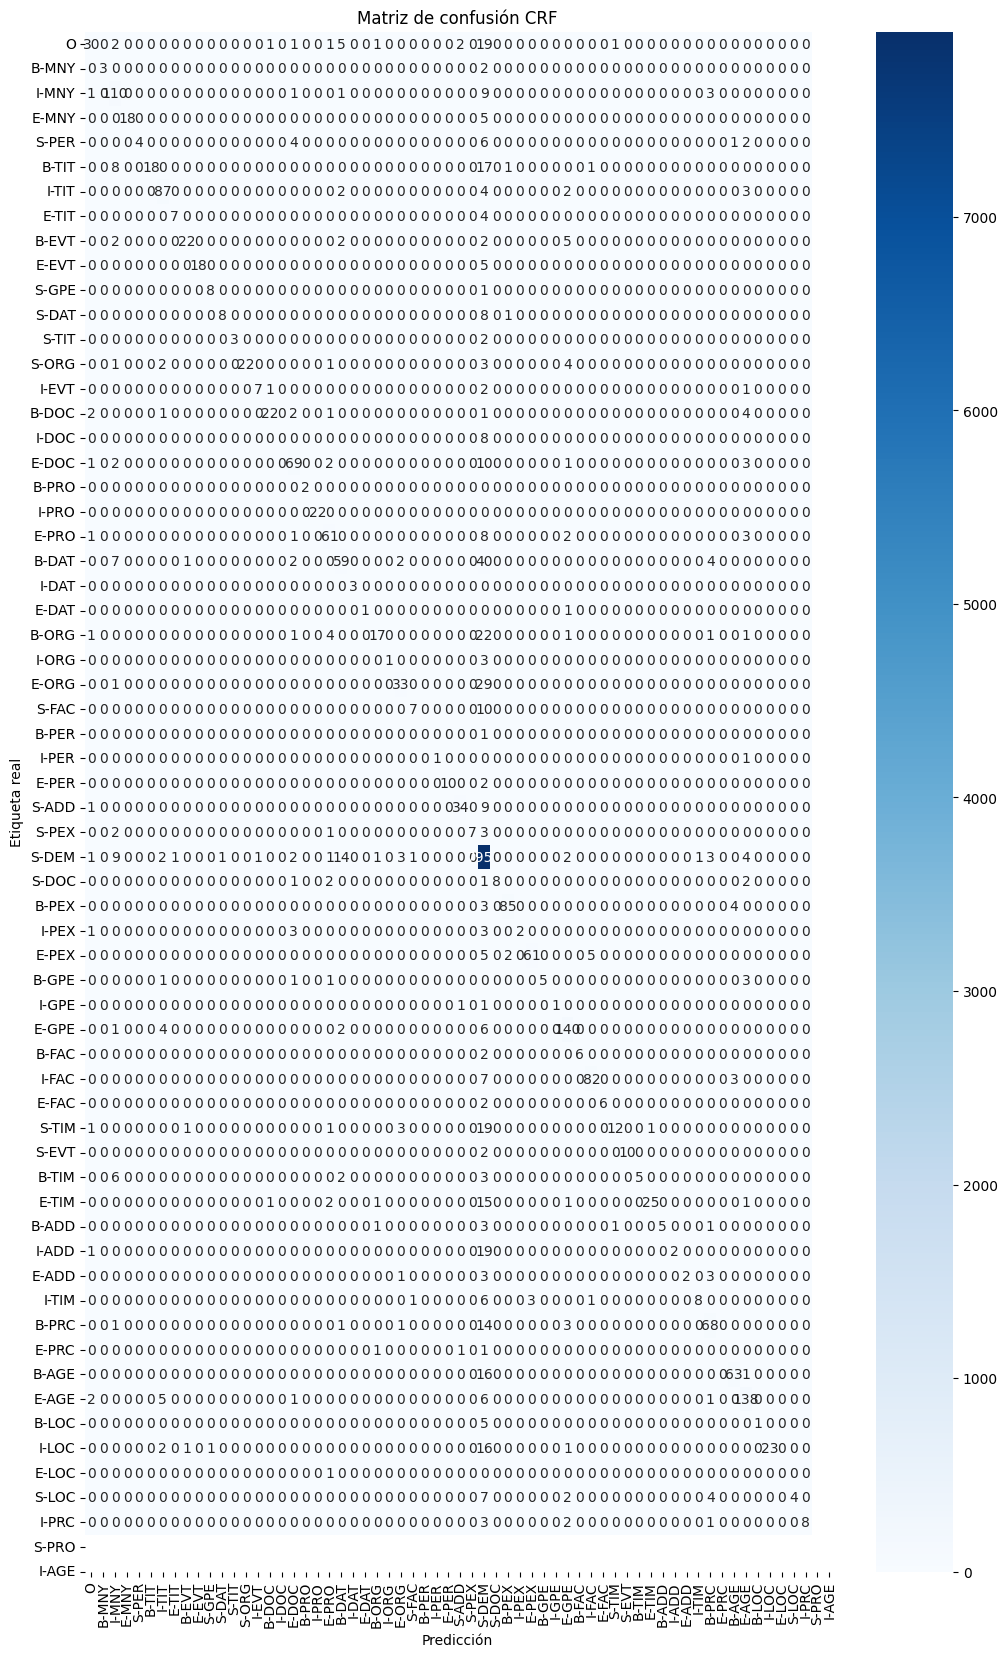

In [26]:
### Visualización de matriz

plt.figure(figsize=(12,20))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=crf.classes_,
            yticklabels=crf.classes_)

plt.title('Matriz de confusión CRF')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta real')

plt.show()